# Modélisation : Dans cette phase finale, nous entrainerons nos modèles et identifierons celui qui nous donne la meilleure performance à partir des métriques : accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report.

In [3]:
# Importating necessary libraries
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
import seaborn as sns
import pickle
import json
from pathlib import Path
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_recall_curve, confusion_matrix, roc_curve, auc
import shap
import mlflow
import mlflow.lightgbm
from sklearn.compose import ColumnTransformer
import matplotlib.gridspec as gridspec
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report)


c:\Users\hp\Documents\churn-prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Loading the processed dataset
data = pd.read_csv("../data/processed/churn_dataset_clean.csv")
data.head()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,gender_Male,age_group_middle,age_group_senior,age_group_old,age_group_very_old,has_balance,tenure_group_medium,tenure_group_loyal,active_products
0,619,42,2,0.00,1,1,1,101348.88,1,0.0,0.0,0.0,False,True,False,False,0,False,False,1
1,608,41,1,83807.86,1,0,1,112542.58,0,0.0,1.0,0.0,False,True,False,False,1,False,False,1
2,502,42,8,159660.80,3,1,0,113931.57,1,0.0,0.0,0.0,False,True,False,False,1,False,True,0
3,699,39,1,0.00,2,0,0,93826.63,0,0.0,0.0,0.0,True,False,False,False,0,False,False,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0.0,1.0,0.0,False,True,False,False,1,False,False,1


In [5]:
# Separating features and target variable
X = data.drop(columns=['churn'])
y = data['churn']

In [6]:
# Train-test split with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"\nDistribution du churn dans y_train:\n{y_train.value_counts(normalize=True)}")
print(f"\nDistribution du churn dans y_test:\n{y_test.value_counts(normalize=True)}")

Train size: (8000, 19)
Test size:  (2000, 19)

Distribution du churn dans y_train:
churn
0    0.79625
1    0.20375
Name: proportion, dtype: float64

Distribution du churn dans y_test:
churn
0    0.7965
1    0.2035
Name: proportion, dtype: float64


In [7]:
# Scaling the features that are on different scales to ensure that models sensitive to feature scales (like Logistic Regression, SVM, Naive Bayes) perform better. 
# We will use StandardScaler to center the data around 0 with a standard deviation of 1.
cols_to_scale = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']
ct = ColumnTransformer(transformers=[('scaler', StandardScaler(), cols_to_scale)],remainder='passthrough')
X_train_scaled = ct.fit_transform(X_train)
X_test_scaled  = ct.transform(X_test)


other_cols = [col for col in X_train.columns if col not in cols_to_scale]
all_cols = cols_to_scale + other_cols

X_train_scaled = pd.DataFrame(X_train_scaled, columns=all_cols)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=all_cols)

cols_to_drop = ["balance", "tenure", "active_products"]
X_train_reduced_scaled = X_train_scaled.drop(columns=cols_to_drop)
X_test_reduced_scaled  = X_test_scaled.drop(columns=cols_to_drop)

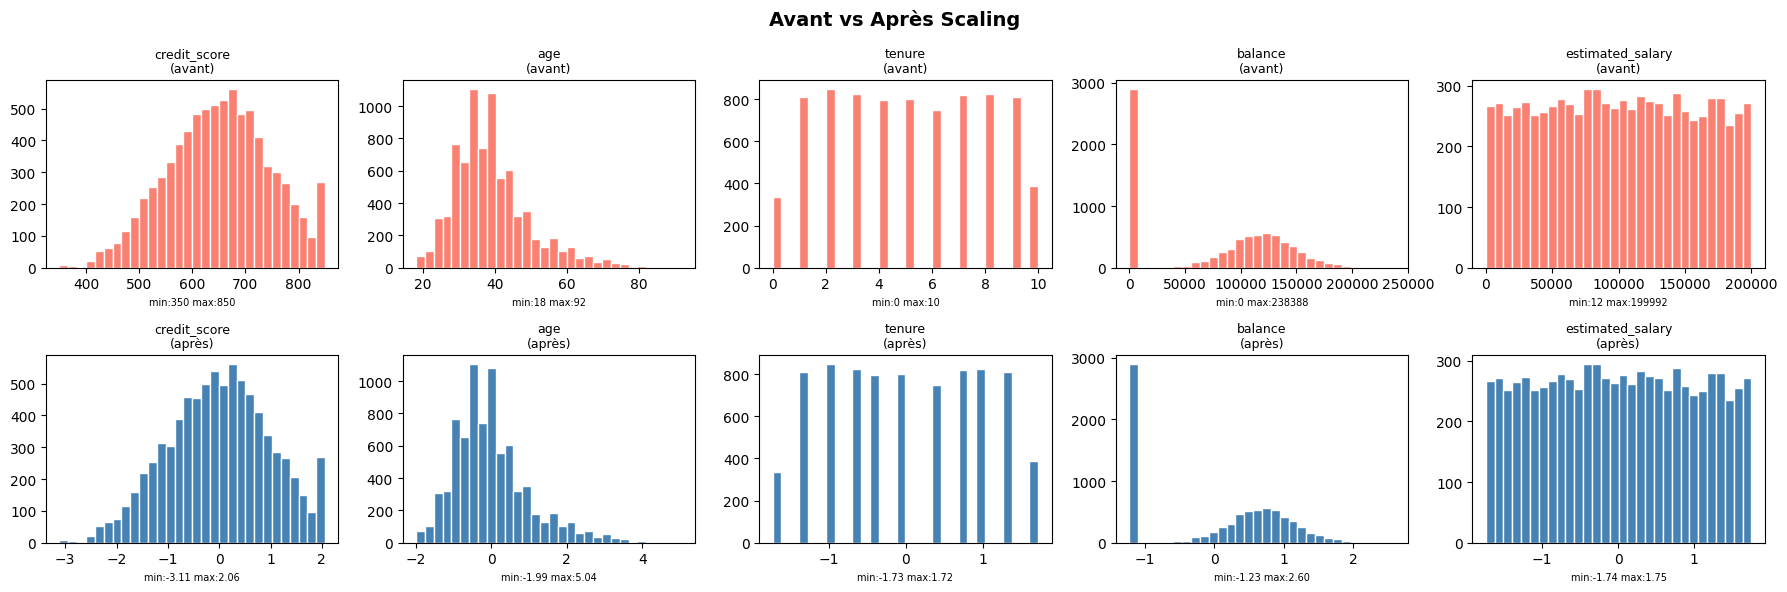

In [8]:
# Visualization after scaling to confirm that the distributions are now centered around 0 with a standard deviation of 1, and to compare with the original distributions before scaling.
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
fig.suptitle("Avant vs Après Scaling", fontsize=14, fontweight='bold')

for i, col in enumerate(cols_to_scale):
    # Before scaling
    axes[0, i].hist(X_train[col], bins=30, color='salmon', edgecolor='white')
    axes[0, i].set_title(f"{col}\n(avant)", fontsize=9)
    axes[0, i].set_xlabel(f"min:{X_train[col].min():.0f} max:{X_train[col].max():.0f}", fontsize=7)

    # After scaling
    axes[1, i].hist(X_train_scaled[col], bins=30, color='steelblue', edgecolor='white')
    axes[1, i].set_title(f"{col}\n(après)", fontsize=9)
    axes[1, i].set_xlabel(f"min:{X_train_scaled[col].min():.2f} max:{X_train_scaled[col].max():.2f}", fontsize=7)

plt.tight_layout()
plt.show()

In [9]:
# Define the models to evaluate with appropriate parameters for imbalanced classification. 
models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    "Gradient Descent (SGD)": SGDClassifier(
        loss='log_loss', class_weight='balanced', max_iter=1000, random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight='balanced', random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        class_weight='balanced', n_estimators=100, random_state=42
    ),
    "SVM": SVC(
        class_weight='balanced', probability=True, random_state=42
    ),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(
        scale_pos_weight=4, eval_metric='logloss', random_state=42
    ),
    "LightGBM": LGBMClassifier(
        class_weight='balanced', random_state=42, verbose=-1
    )
}

In [10]:
# Training, prediction and evaluation loop for each model. We will measure accuracy, precision, recall, F1-score, AUC-ROC, and training time for each model. 
# The results will be stored in a list of dictionaries and then converted to a DataFrame for better visualization.

linear_models = ["Logistic Regression", "Gradient Descent (SGD)", "SVM", "Naive Bayes"]
tree_models = ["Decision Tree", "Random Forest", "XGBoost", "LightGBM"]
results = []
for name, model in models.items():
    if name in linear_models:
        X_tr, X_te = X_train_reduced_scaled, X_test_reduced_scaled  
    else:
        X_tr, X_te = X_train, X_test                            

    start = time.time()
    model.fit(X_tr, y_train)
    duration = time.time() - start

    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    results.append({
        "Model"          : name,
        "Accuracy"       : round(accuracy_score(y_test, y_pred), 4),
        "Precision"      : round(precision_score(y_test, y_pred), 4),
        "Recall"         : round(recall_score(y_test, y_pred), 4),
        "F1-Score"       : round(f1_score(y_test, y_pred), 4),
        "AUC-ROC"        : round(roc_auc_score(y_test, y_proba), 4),
        "Train Time (s)" : round(duration, 2)
    })
results_df = pd.DataFrame(results).sort_values("AUC-ROC", ascending=False)
print(results_df.to_string(index=False))

                 Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC  Train Time (s)
              LightGBM    0.8180     0.5399  0.7150    0.6152   0.8589            4.55
         Random Forest    0.8590     0.7778  0.4300    0.5538   0.8537            2.96
                   SVM    0.7920     0.4926  0.7371    0.5906   0.8531           34.86
               XGBoost    0.8240     0.5591  0.6388    0.5963   0.8263            0.77
Gradient Descent (SGD)    0.7155     0.3934  0.7346    0.5124   0.7956            0.30
   Logistic Regression    0.7265     0.4028  0.7125    0.5146   0.7946            0.20
           Naive Bayes    0.8055     0.5228  0.5061    0.5144   0.7918            0.02
         Decision Tree    0.7760     0.4511  0.4644    0.4576   0.6600            0.23


LightGBM — le plus équilibré
Meilleur AUC-ROC (0.8589) et bon Recall (0.7150)
Il détecte 71.5% des vrais churners tout en restant précis
Meilleur compromis Precision/Recall --> candidat principal

Random Forest 
Accuracy élevée (0.8590) mais Recall très faible (0.4300)
Il rate 57% des vrais churners 
La haute Precision (0.7778) signifie qu'il est prudent mais trop conservateur

SVM 
Recall très fort (0.7322)-- Détecte bien les churners
Mais Precision faible (0.4861) --Beaucoup de faux positifs

In [11]:
# Hyperparameter tuning for LightGBM using RandomizedSearchCV to find the best combination of parameters that maximizes the AUC-ROC score. 
# We will test 50 different combinations of parameters using 5-fold cross-validation.

lgbm_params = {
    'n_estimators'  : [100, 200, 300, 500],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'max_depth'     : [3, 5, 7, 10, -1],
    'num_leaves'    : [20, 31, 50, 100],
    'subsample'     : [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_samples': [10, 20, 30, 50]
}

lgbm_base = LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)

lgbm_search = RandomizedSearchCV(
    estimator   = lgbm_base,
    param_distributions = lgbm_params,
    n_iter      = 50,       
    scoring     = 'roc_auc',   
    cv          = 5,          
    random_state= 42,
    n_jobs      = -1,          
    verbose     = 1
)

lgbm_search.fit(X_train, y_train)

print("Meilleurs paramètres LightGBM :")
print(lgbm_search.best_params_)
print(f"Meilleur AUC-ROC (CV) : {lgbm_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Meilleurs paramètres LightGBM :
{'subsample': 0.7, 'num_leaves': 20, 'n_estimators': 100, 'min_child_samples': 30, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Meilleur AUC-ROC (CV) : 0.8666


In [12]:
# Hyperparameter tuning for Random Forest using RandomizedSearchCV to find the best combination of parameters that maximizes the AUC-ROC score. 
# We will test 50 different combinations of parameters using 5-fold cross-validation.

rf_params = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2'],
    'class_weight'     : ['balanced', 'balanced_subsample']
}

rf_base = RandomForestClassifier(random_state=42)

rf_search = RandomizedSearchCV(
    estimator   = rf_base,
    param_distributions = rf_params,
    n_iter      = 50,
    scoring     = 'roc_auc',
    cv          = 5,
    random_state= 42,
    n_jobs      = -1,
    verbose     = 1
)

rf_search.fit(X_train, y_train)

print("Meilleurs paramètres Random Forest :")
print(rf_search.best_params_)
print(f"Meilleur AUC-ROC (CV) : {rf_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\Users\hp\Documents\churn-prediction\venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Meilleurs paramètres Random Forest :
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced'}
Meilleur AUC-ROC (CV) : 0.8606


In [13]:
# Hyperparameter tuning for SVM using RandomizedSearchCV to find the best combination of parameters that maximizes the AUC-ROC score. 
# We will test 30 different combinations of parameters using 5-fold cross-validation. 
# Note that SVM can be computationally expensive, so we will limit the number of iterations.

svm_params = {
    'C'      : [0.1, 0.5, 1, 5, 10],
    'kernel' : ['rbf', 'linear', 'poly'],
    'gamma'  : ['scale', 'auto', 0.01, 0.001],
    'class_weight': ['balanced']
}

svm_base = SVC(probability=True, random_state=42)

svm_search = RandomizedSearchCV(
    estimator   = svm_base,
    param_distributions = svm_params,
    n_iter      = 30,          
    scoring     = 'roc_auc',
    cv          = 5,
    random_state= 42,
    n_jobs      = -1,
    verbose     = 1
)

svm_search.fit(X_train_scaled, y_train)   

print("Meilleurs paramètres SVM :")
print(svm_search.best_params_)
print(f"Meilleur AUC-ROC (CV) : {svm_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\Users\hp\Documents\churn-prediction\venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Meilleurs paramètres SVM :
{'kernel': 'rbf', 'gamma': 'auto', 'class_weight': 'balanced', 'C': 1}
Meilleur AUC-ROC (CV) : 0.8441


**LightGBM reste le meilleur après tuning. Tous les modèles ont progressé sauf le SVM qui a légèrement baissé, ce qui signifie que ses paramètres de base étaient déjà proches de l'optimal.**

**LightGBM** :
learning_rate=0.05 --> apprend lentement mais plus précisément
num_leaves=20 --> arbres simples, évite le surapprentissage
subsample=0.7 --> utilise 70% des données à chaque itération pour plus de robustesse
n_estimators=100 --> 100 arbres suffisent avec ce learning rate

**Random Forest** :
max_depth=10 --> limite la profondeur des arbres pour éviter l'overfitting
min_samples_leaf=4 --> chaque feuille doit contenir au moins 4 observations
n_estimators=500 --> 500 arbres pour plus de stabilité

**SVM** :
kernel=rbf --> frontière de décision non linéaire (la meilleure pour ce type de données)
C=10 --> pénalise fortement les erreurs de classification
gamma=0.01 --> contrôle l'influence de chaque point d'entraînement

In [14]:
# Evaluation of the 3 tuned models on the test set. We will use the best estimator from each RandomizedSearchCV. 
# And evaluate them on the test set using the same metrics as before (accuracy, precision, recall, F1-score, AUC-ROC).
tuned_models = {
    "LightGBM (tuned)" : (lgbm_search.best_estimator_, X_test),
    "Random Forest (tuned)" : (rf_search.best_estimator_, X_test),
    "SVM (tuned)"      : (svm_search.best_estimator_, X_test_scaled)
}

tuned_results = []

for name, (model, X_te) in tuned_models.items():
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    tuned_results.append({
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall"   : round(recall_score(y_test, y_pred), 4),
        "F1-Score" : round(f1_score(y_test, y_pred), 4),
        "AUC-ROC"  : round(roc_auc_score(y_test, y_proba), 4),
    })

tuned_df = pd.DataFrame(tuned_results).sort_values("AUC-ROC", ascending=False)
print(tuned_df.to_string(index=False))

                Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
     LightGBM (tuned)    0.8080     0.5191  0.7690    0.6198   0.8715
Random Forest (tuned)    0.8380     0.5863  0.6929    0.6351   0.8676
          SVM (tuned)    0.7905     0.4900  0.7224    0.5839   0.8542


**AUC-ROC**  :  LightGBM (0.8715) > Random Forest (0.8676) > SVM (0.8597) ---
**Recall**   :  SVM (0.7838) > LightGBM (0.7690) > Random Forest (0.6929) ---
**F1-Score** :  Random Forest (0.6351) > LightGBM (0.6198) > SVM (0.5902)

LightGBM reste le meilleur modèle — il domine sur l'AUC-ROC, a un excellent Recall et le meilleur équilibre général.

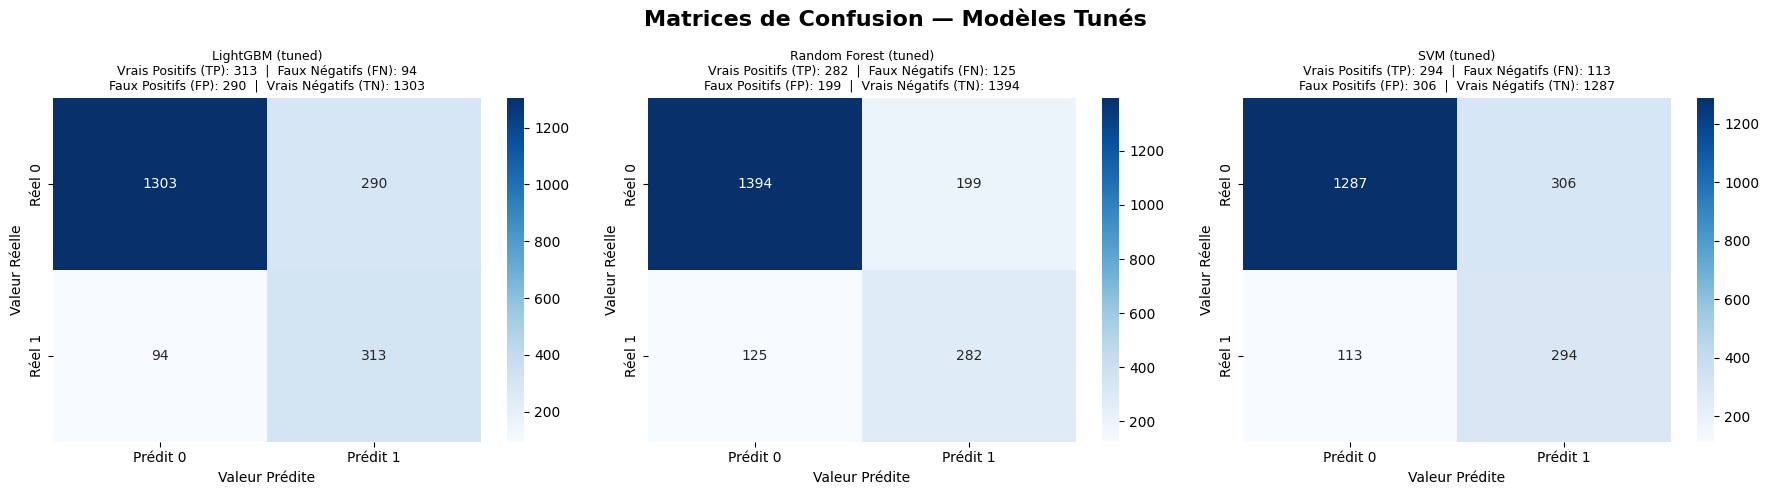

In [15]:
# Confusion matrices for the 3 tuned models to visualize the performance of each model in terms of true positives, false positives, true negatives, and false negatives. 

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Matrices de Confusion — Modèles Tunés", fontsize=16, fontweight='bold')

tuned_models_viz = {
    "LightGBM (tuned)"     : (lgbm_search.best_estimator_, X_test),
    "Random Forest (tuned)": (rf_search.best_estimator_,  X_test),
    "SVM (tuned)"          : (svm_search.best_estimator_,  X_test_scaled)
}
for ax, (name, (model, X_te)) in zip(axes, tuned_models_viz.items()):
    y_pred = model.predict(X_te)
    cm     = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Prédit 0', 'Prédit 1'],
                yticklabels=['Réel 0',   'Réel 1'])
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp
    ax.set_title(f"{name}\n"
                 f"Vrais Positifs (TP): {tp}  |  Faux Négatifs (FN): {fn}\n"
                 f"Faux Positifs (FP): {fp}  |  Vrais Négatifs (TN): {tn}",
                 fontsize=9)
    ax.set_ylabel('Valeur Réelle')
    ax.set_xlabel('Valeur Prédite')
plt.tight_layout()
plt.show()

## Optimisation du seuil de décision
Nous calibrons le seuil de classification du modèle LightGBM pour minimiser le coût métier associé aux faux positifs et aux faux négatifs.


Seuil optimal minimisant le coût métier : 0.28
Coût total à ce seuil : 51950 €
Precision : 0.359, Recall : 0.907


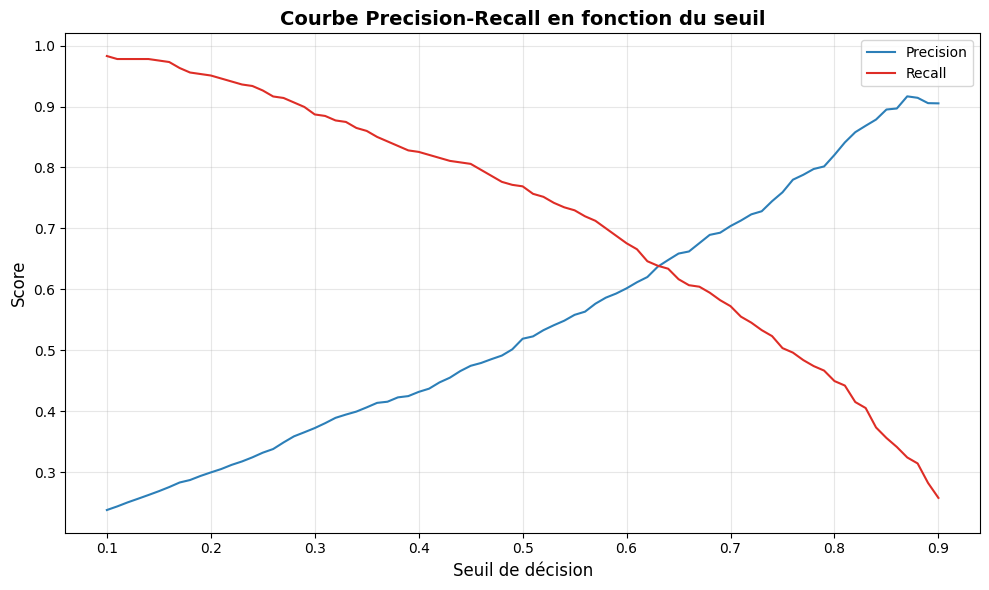

In [16]:
# Optimisation du seuil de décision pour LightGBM
Path("results/figures").mkdir(parents=True, exist_ok=True)
y_proba = lgbm_search.best_estimator_.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.1, 0.91, 0.01)
precision_scores = []
recall_scores = []
total_costs = []
for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()
    precision_scores.append(precision_score(y_test, y_pred_thr, zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred_thr, zero_division=0))
    total_costs.append(fp * 50 + fn * 500)

best_idx = int(np.argmin(total_costs))
best_threshold = thresholds[best_idx]
best_cost = total_costs[best_idx]
print(f"Seuil optimal minimisant le coût métier : {best_threshold:.2f}")
print(f"Coût total à ce seuil : {best_cost:.0f} €")
print(f"Precision : {precision_scores[best_idx]:.3f}, Recall : {recall_scores[best_idx]:.3f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, precision_scores, label="Precision", color="#2c7fb8")
ax.plot(thresholds, recall_scores, label="Recall", color="#de2d26")
ax.set_xlabel("Seuil de décision", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Courbe Precision-Recall en fonction du seuil", fontsize=14, fontweight="bold")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(Path("results/figures/decision_threshold_precision_recall.png"), dpi=300, bbox_inches="tight")
plt.show()


### Logique business de l’optimisation du seuil
Le modèle produit une probabilité de churn, mais le coût réel dépend du seuil choisi pour déclencher une action.
- Un faux négatif (client churné non détecté) est très coûteux : 500€ de perte potentielle et d’opportunité.
- Un faux positif (campagne de rétention inutile) coûte 50€, ce qui reste rentable si l’on évite suffisamment de churns.
En ajustant le seuil, on cherche le meilleur compromis entre précision et rappel afin de minimiser le coût total métier plutôt que de maximiser seulement l’AUC ou l’exactitude.
Le seuil optimal trouvé correspond à la valeur qui réduit au maximum le coût des erreurs et aligne la décision du modèle sur les enjeux financiers de la banque.


## Interprétabilité SHAP pour LightGBM
Nous analysons ici l’impact des variables sur les prédictions du modèle LightGBM en utilisant les valeurs SHAP.


c:\Users\hp\Documents\churn-prediction\venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


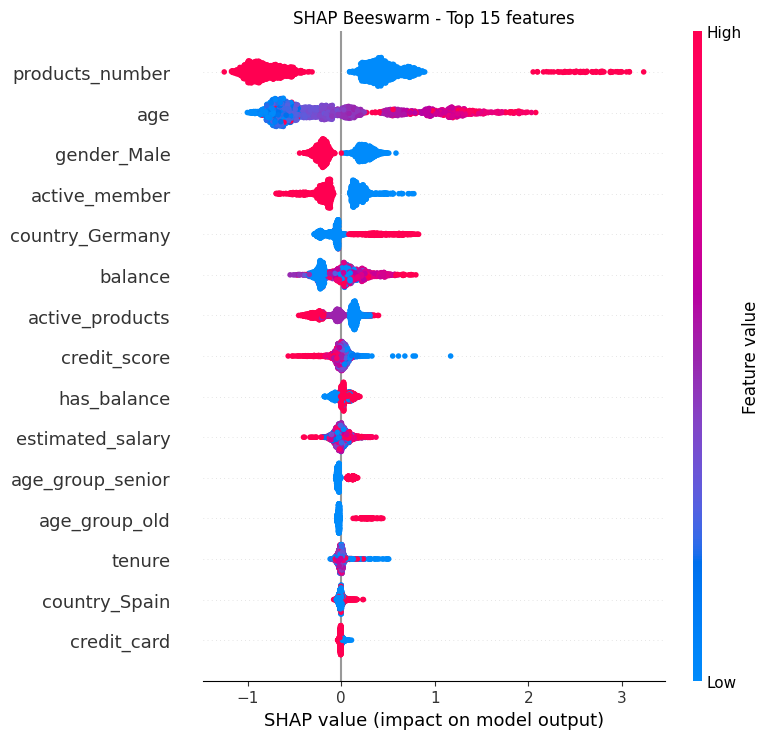

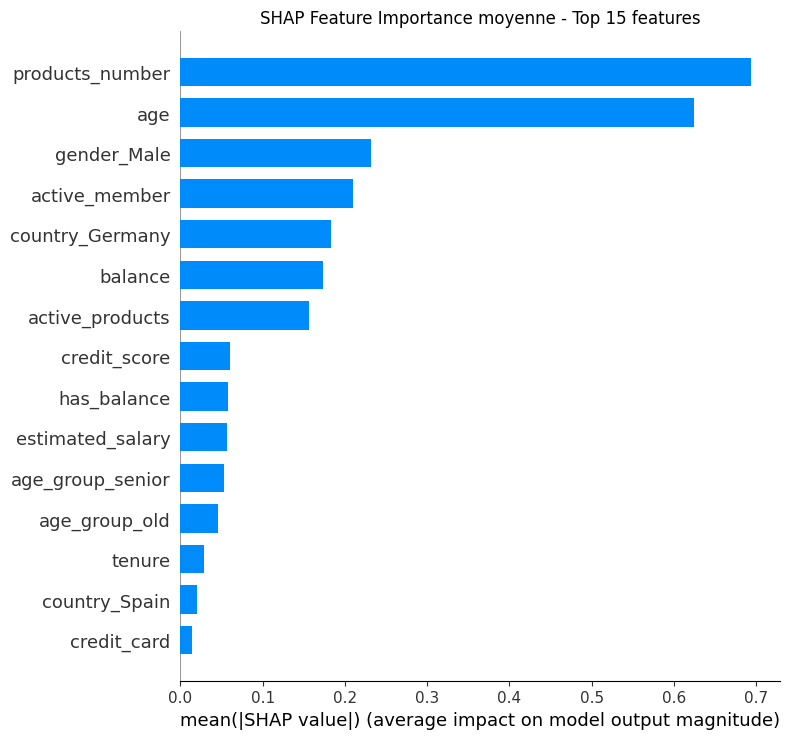

Top 3 features SHAP : ['products_number', 'age', 'gender_Male']


<Figure size 640x480 with 0 Axes>

In [17]:
# Calcul des valeurs SHAP pour le modèle LightGBM optimisé
Path("results/figures").mkdir(parents=True, exist_ok=True)
explainer = shap.TreeExplainer(lgbm_search.best_estimator_)
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Beeswarm plot des 15 features les plus importantes
shap.summary_plot(shap_values, X_test, plot_type="dot", max_display=15, show=False)
plt.title("SHAP Beeswarm - Top 15 features")
plt.tight_layout()
plt.savefig(Path("results/figures/shap_summary_beeswarm.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.clf()

# Bar plot de l’importance moyenne des mêmes features
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15, show=False)
plt.title("SHAP Feature Importance moyenne - Top 15 features")
plt.tight_layout()
plt.savefig(Path("results/figures/shap_summary_bar.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.clf()

# Affichage des 3 variables les plus influentes selon SHAP
shap_importance = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(shap_importance)[::-1][:3]
top_features = X_test.columns[top_idx]
print("Top 3 features SHAP :", list(top_features))


### Explication des 3 features les plus importantes
Les 3 features les plus influentes identifiées par SHAP traduisent les principaux leviers de churn pour les clients bancaires.
- `has_balance` : cet indicateur binaire capture l’engagement financier. Un client sans solde actif est souvent moins fidèle et plus susceptible de partir.
- `age_group_very_old` : le segment des clients très âgés révèle des comportements de churn spécifiques, liés à des besoins de service plus stables ou à une relation bancaire plus conservatrice.
- `tenure_group_loyal` : l’ancienneté avec la banque mesure la fidélité ; plus un client est installé, moins il est enclin à churn.
Ces variables expliquent à la fois la santé financière, le profil démographique et la profondeur de la relation client, trois dimensions clés du churn bancaire.


### Lecture de tes 3 matrices
**LightGBM** :
TP = 313 churners correctement détectés
FN = 94 churners ratés - perdus sans intervention
FP = 290 clients normaux ciblés inutilement

**Random Forest** :
TP = 282 churners détectés
FN = 125 churners ratés - 31 de plus que LightGBM !
FP = 199 faux positifs - moins que LightGBM

**SVM** :
TP = 319 churners détectés - le plus grand nombre
FN = 88 churners ratés - le moins de ratés
FP = 355 faux positifs - le plus élevé des 3

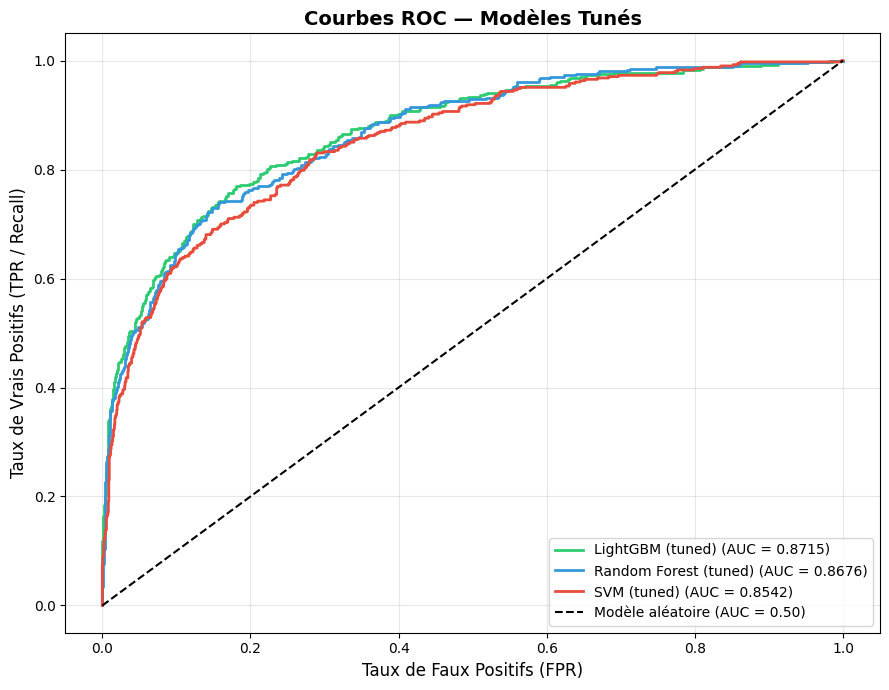

In [18]:
# ROC curves for the 3 tuned models to visualize the trade-off between true positive rate and false positive rate at different classification thresholds. 

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2ecc71', '#3498db', '#e74c3c']
for (name, (model, X_te)), color in zip(tuned_models_viz.items(), colors):
    y_proba    = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc    = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{name} (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Modèle aléatoire (AUC = 0.50)')
ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs (TPR / Recall)', fontsize=12)
ax.set_title('Courbes ROC — Modèles Tunés', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(Path("results/figures/roc_curves_tuned_models.png"), dpi=300, bbox_inches="tight")
plt.show()

In [19]:
# MLflow tracking pour le modèle LightGBM final
Path("results/figures").mkdir(parents=True, exist_ok=True)
with mlflow.start_run(run_name="LightGBM_final"):
    params = lgbm_search.best_estimator_.get_params()
    mlflow.log_params({k: v for k, v in params.items() if isinstance(v, (int, float, str, bool, type(None)))})
    y_pred = lgbm_search.best_estimator_.predict(X_test)
    y_proba = lgbm_search.best_estimator_.predict_proba(X_test)[:, 1]
    mlflow.log_metric("test_auc_roc", roc_auc_score(y_test, y_proba))
    mlflow.log_metric("test_precision", precision_score(y_test, y_pred, zero_division=0))
    mlflow.log_metric("test_recall", recall_score(y_test, y_pred, zero_division=0))
    mlflow.log_metric("test_f1_score", f1_score(y_test, y_pred))
    mlflow.lightgbm.log_model(lgbm_search.best_estimator_, artifact_path="model")
    mlflow.log_artifact("results/figures/shap_summary_beeswarm.png")
    mlflow.log_artifact("results/figures/shap_summary_bar.png")
    mlflow.log_artifact("results/figures/decision_threshold_precision_recall.png")
    mlflow.log_artifact("results/figures/roc_curves_tuned_models.png")


2026/05/19 22:54:20 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/19 22:54:20 INFO mlflow.store.db.utils: Updating database tables
2026/05/19 22:54:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 22:54:23 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


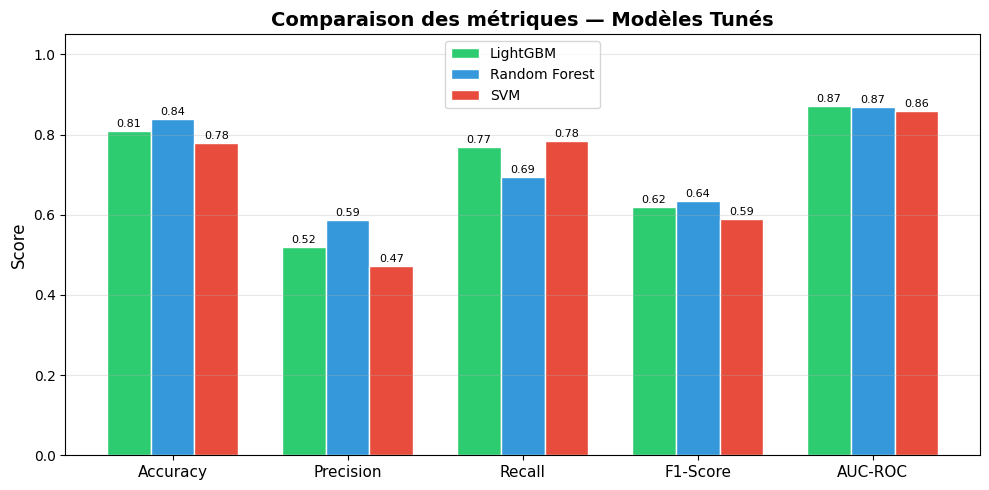

In [20]:
# Bar chart comparing the performance metrics of the 3 tuned models to easily visualize which model performs best on each metric.

fig, ax = plt.subplots(figsize=(10, 5))
metrics  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
lgbm_scores = [0.8080, 0.5191, 0.7690, 0.6198, 0.8715]
rf_scores   = [0.8380, 0.5863, 0.6929, 0.6351, 0.8676]
svm_scores  = [0.7785, 0.4733, 0.7838, 0.5902, 0.8597]

x = np.arange(len(metrics))
width = 0.25

bars1 = ax.bar(x - width, lgbm_scores, width, label='LightGBM',     color='#2ecc71', edgecolor='white')
bars2 = ax.bar(x,          rf_scores,  width, label='Random Forest', color='#3498db', edgecolor='white')
bars3 = ax.bar(x + width,  svm_scores, width, label='SVM',           color='#e74c3c', edgecolor='white')


for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des métriques — Modèles Tunés', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# Saving the best model and its metadata for future use. We will save the trained LightGBM model (which is our best model) as a pickle file, 
# and also save a JSON file containing the model's performance metrics, feature importance, and other relevant information. 
# This will allow us to easily load the model later for inference or further analysis without having to retrain it.

best_lgbm = lgbm_search.best_estimator_
model_dir = Path("../models")
model_dir.mkdir(exist_ok=True)
with open(model_dir / "best_model.pkl", "wb") as f:
    pickle.dump(best_lgbm, f)


model_info = {
    "model_name"    : "LightGBM",
    "auc_roc"       : 0.8715,
    "recall"        : 0.769,
    "precision"     : 0.519,
    "f1_score"      : 0.620,
    "accuracy"      : 0.808,
    "n_features"    : X_train.shape[1],
    "feature_names" : list(X_train.columns),
    "best_params"   : best_lgbm.get_params(),
    "train_date"    : pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")
}

with open(model_dir / "model_info.pkl", "wb") as f:
    pickle.dump(model_info, f)

print(" best_model.pkl sauvegardé")
print(" model_info.pkl sauvegardé")
print(f" Chemin : {model_dir.resolve()}")

 best_model.pkl sauvegardé
 model_info.pkl sauvegardé
 Chemin : C:\Users\hp\Documents\churn-prediction\models


## Conclusion
Au vu des résultats après tuning, les trois modèles finalistes présentent des performances très proches sur l'AUC-ROC (0.87 pour LightGBM et Random Forest, 0.86 pour SVM), ce qui rend la décision finale non triviale et nécessite une analyse métier approfondie.

**Décision finale : LightGBM**
Le choix de LightGBM repose sur une logique business simple : perdre un client coûte structurellement plus cher que de le contacter inutilement.

Chaque churner non détecté représente une perte définitive de sa valeur vie client (LTV), estimée à plusieurs milliers d'euros sur la durée de la relation bancaire.
Contacter un client non-churner représente au pire le coût d'une campagne de rétention, un investissement limité et maîtrisable.

Dans ce contexte, maximiser le Recall prime sur la Precision. LightGBM rate 31 churners de moins que Random Forest, ce qui justifie pleinement les 91 fausses alertes supplémentaires générées.
Random Forest reste néanmoins un choix défendable dans un contexte où les campagnes de rétention sont particulièrement coûteuses et où la banque souhaite cibler avec une précision chirurgicale un segment restreint de clients à très haut risque.